# Bayesian Rate-and-State GMSL Model

Extends the instantaneous Bayesian level-space model with a **state variable** $S(t)$ that captures the lagged response of deep ocean thermal expansion and ice-sheet dynamics to surface temperature forcing.

**Generative model:**
$$
\frac{dS}{dt} = \frac{T(t) - S(t)}{\tau}
$$
$$
\dot{H}(t) = a\,T(t)^2 + b\,T(t) + c + d\,(S(t) - T(t))
$$
$$
H(t) = H_0 + \int_0^t \dot{H}(\xi)\,d\xi
$$
$$
H_{\text{obs}}(t) \sim \mathcal{N}\bigl(H(t),\; \sigma_H(t)^2\bigr)
$$

**Physical interpretation:** During warming, $S < T$ (the state lags temperature), so $d \cdot (S - T) < 0$ — the realised SLR rate is *less* than the equilibrium rate because slow components (deep ocean, ice sheets) have not yet fully responded. After temperature stabilises, $S$ catches up and the disequilibrium vanishes.

**Limiting behaviour:** As $\tau \to 0$, $S \to T$ and $d \cdot (S - T) \to 0$, recovering the instantaneous model $\text{rate} = a\,T^2 + b\,T + c$.

**Key parameters:**
- $\tau$: Effective relaxation time (years) — captures the dominant ocean/ice sheet response timescale
- $d$: Disequilibrium strength (mm/yr/°C) — magnitude of committed but unrealised SLR

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from bayesian_models import (
    build_level_design_vectors,
    fit_bayesian_level,
    fit_bayesian_state_level,
    fit_satellite_era_quadratic,
    solve_state_ode,
    calibrate_exponential_prior,
    prior_predictive_rate_check,
)
from slr_analysis import (
    compute_kinematics,
)
from slr_projections import (
    project_gmsl_ensemble,
    project_gmsl_state_ensemble,
)

# Constants
from slr_forecast.config import BASELINE_YEAR, Z_90
from slr_forecast import M_TO_MM
N_SAMPLES = 5000  # Higher than config (2000) for 7-dim MCMC convergence
N_WALKERS = 64
N_BURNIN = 3000   # more burn-in for 7-dim nonlinear model

# Paths
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data'
H5_PATH = DATA_DIR / 'processed' / 'slr_processed_data.h5'
FIG_DIR = BASE_DIR / 'figures'

sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print(f'Constants: BASELINE_YEAR={BASELINE_YEAR}, '
      f'N_SAMPLES={N_SAMPLES}, N_WALKERS={N_WALKERS}, '
      f'N_BURNIN={N_BURNIN}')

Constants: BASELINE_YEAR=2000.0, N_SAMPLES=5000, N_WALKERS=64, N_BURNIN=3000


## §1 Data Loading

Load Frederikse GMSL + Berkeley Earth temperature data, plus IPCC temperature projections for forward runs.

In [2]:
# ============================================================
# Load data from HDF5
# ============================================================
with pd.HDFStore(str(H5_PATH), 'r') as store:
    config = store['/config']
    df_frederikse = store['/harmonized/df_frederikse_h']
    df_berkeley = store['/harmonized/df_berkeley_h']
    df_nasa_gmsl = store['/harmonized/df_nasa_gmsl_h']

    # Temperature projections for forward runs
    temp_projections_raw = {}
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections_raw[name] = store[f'/projections/temp/{key}']

    # IPCC GMSL for comparison
    ipcc_gmsl = {}
    ssp_gmsl_keys = {
        'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
        'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
    }
    for name, key in ssp_gmsl_keys.items():
        ipcc_gmsl[name] = store[f'/projections/gmsl/{key}']

# Extract GMSL observations (Frederikse — for level-space model)
H_obs_full = df_frederikse['gmsl'].values            # meters
sigma_gmsl = df_frederikse['gmsl_sigma'].values      # meters
tws_sigma = df_frederikse['tws_sigma'].values        # meters
obs_years = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_frederikse.index
])

# NASA satellite altimetry (for rate prior — sub-monthly, 1993–2025)
nasa_time = df_nasa_gmsl['decimal_year'].values
nasa_gmsl = df_nasa_gmsl['gmsl'].values              # meters, GIA applied
ABLAIN_COV_PATH = str(DATA_DIR / 'raw' / 'gmslr'
                       / 'ablain2019_gmsl_error_covariance.nc')

# Monthly temperature (full record for ODE and projection spin-up)
T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# Restrict to observation period for calibration
mask_berk = ((time_monthly_all >= obs_years[0]) &
             (time_monthly_all <= obs_years[-1]))
T_monthly_fit = T_monthly_all[mask_berk]
time_monthly_fit = time_monthly_all[mask_berk]

# --- Rebaseline SSP temperatures from pre-industrial (~1850-1900)
# to the Berkeley Earth 1995-2005 baseline used for model calibration.
# Without this, rate = a*T² + b*T + c is evaluated at ~0.75°C too high,
# producing vastly inflated projections (quadratic amplification).
df_berk_annual = df_berkeley.resample('YE').mean().dropna(subset=['temperature'])
berk_annual_years = np.array([t.year + 0.5 for t in df_berk_annual.index])
berk_annual_T = df_berk_annual['temperature'].values

temp_projections = {}
for ssp_name, temp_df in temp_projections_raw.items():
    df_rb = temp_df.copy()
    T_proj = df_rb['temperature'].values.copy()
    if 'decimal_year' in df_rb.columns:
        t_proj = df_rb['decimal_year'].values
    else:
        t_proj = np.array([t.year + (t.month - 0.5) / 12 for t in df_rb.index])
    # Match IPCC and Berkeley Earth at the overlap year
    ipcc_first_year = t_proj[0]
    idx_overlap = np.argmin(np.abs(berk_annual_years - ipcc_first_year))
    berk_at_overlap = berk_annual_T[idx_overlap]
    ipcc_at_overlap = T_proj[0]
    temp_baseline_offset = ipcc_at_overlap - berk_at_overlap
    df_rb['temperature'] = T_proj - temp_baseline_offset
    if 'temperature_lower' in df_rb.columns:
        df_rb['temperature_lower'] -= temp_baseline_offset
        df_rb['temperature_upper'] -= temp_baseline_offset
    temp_projections[ssp_name] = df_rb

print(f'Frederikse GMSL: {len(H_obs_full)} annual obs, '
      f'{obs_years[0]:.1f}\u2013{obs_years[-1]:.1f}')
print(f'NASA altimetry:  {len(nasa_gmsl)} obs (~10-day), '
      f'{nasa_time[0]:.1f}\u2013{nasa_time[-1]:.1f}')
print(f'Berkeley Earth T: {len(T_monthly_fit)} monthly obs, '
      f'{time_monthly_fit[0]:.1f}\u2013{time_monthly_fit[-1]:.1f}')
print(f'Full T record: {len(T_monthly_all)} months, '
      f'{time_monthly_all[0]:.1f}\u2013{time_monthly_all[-1]:.1f}')
print(f'Temperature baseline offset (pre-industrial \u2192 Berkeley Earth): '
      f'{temp_baseline_offset:.3f} \u00b0C')
# Verify alignment
_t0 = t_proj[0]
_T0 = temp_projections['SSP2-4.5']['temperature'].iloc[0]
_Tb = np.interp(_t0, berk_annual_years, berk_annual_T)
print(f'Verification at {_t0:.0f}: SSP T = {_T0:.3f} \u00b0C, '
      f'Berkeley T = {_Tb:.3f} \u00b0C (diff = {_T0 - _Tb:.4f} \u00b0C)')

Frederikse GMSL: 119 annual obs, 1900.5–2018.5
NASA altimetry:  1191 obs (~10-day), 1993.0–2025.3
Berkeley Earth T: 1417 monthly obs, 1900.5–2018.5
Full T record: 2100 months, 1850.0–2025.0
Temperature baseline offset (pre-industrial → Berkeley Earth): 0.898 °C
Verification at 2015: SSP T = 0.213 °C, Berkeley T = 0.285 °C (diff = -0.0722 °C)


## §2 Observation Uncertainty

Same as the instantaneous model:
$$
\sigma(t)^2 = \sigma_{\text{gmsl}}(t)^2 + \sigma_{\text{TWS}}(t)^2 + \sigma_{\text{extra}}^2
$$
with dam-filling structural uncertainty Gaussian hump centred on 1970 (cf. Frederikse et al., 2020).

In [3]:
# ============================================================
# Observation uncertainty due to dam impoundment
# ============================================================
DAM_PEAK = 1970.0
DAM_WIDTH = 25.0
DAM_AMPLITUDE = 0.003  # 3 mm

dam_extra = DAM_AMPLITUDE * np.exp(
    -0.5 * ((obs_years - DAM_PEAK) / DAM_WIDTH)**2
)
sigma_tws_total = np.sqrt(tws_sigma**2 + dam_extra**2)
sigma_obs_fixed = np.sqrt(sigma_gmsl**2 + sigma_tws_total**2)

print(f'sigma_obs range: {sigma_obs_fixed.min()*M_TO_MM:.1f} to '
      f'{sigma_obs_fixed.max()*M_TO_MM:.1f} mm')

sigma_obs range: 4.4 to 20.6 mm


## §3 Design Vectors

Pre-compute the $\tau$-independent design vectors ($I_2 = \int T^2$, $I_1 = \int T$, $I_0 = t - t_0$) and demonstrate the state variable $S(t)$ for several values of $\tau$.

Since $\tau$ varies at each MCMC step, $I_S = \int (S - T)\,d\tau$ must be recomputed inside the log-probability function. Only $I_2$, $I_1$, $I_0$ are constant.

Design vectors: 119 obs points from 1417 monthly grid


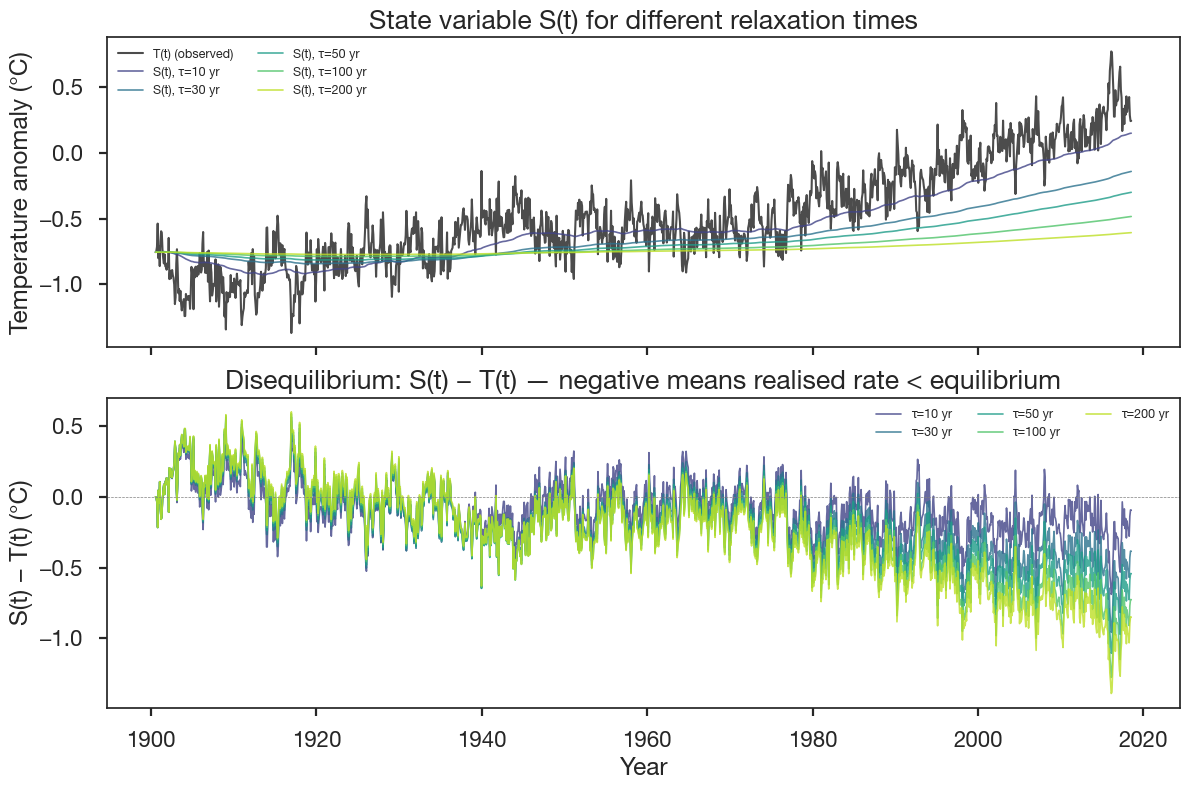


Disequilibrium at 2018 for each τ:
  τ=  10 yr: S-T = -0.094 °C
  τ=  30 yr: S-T = -0.384 °C
  τ=  50 yr: S-T = -0.543 °C
  τ= 100 yr: S-T = -0.727 °C
  τ= 200 yr: S-T = -0.850 °C


In [4]:
# ============================================================
# Build τ-independent design vectors
# ============================================================
dv = build_level_design_vectors(
    temperature_monthly=T_monthly_fit,
    time_monthly=time_monthly_fit,
    obs_times=obs_years,
)

I2_obs = dv['I2_obs']
I1_obs = dv['I1_obs']
I0_obs = dv['I0_obs']
obs_idx = dv['obs_idx']

print(f'Design vectors: {len(I2_obs)} obs points from '
      f'{len(T_monthly_fit)} monthly grid')

# ============================================================
# Demonstrate S(t) for several τ values
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: T(t) and S(t) for various τ
ax = axes[0]
ax.plot(time_monthly_fit, T_monthly_fit, 'k-', lw=1.5, alpha=0.7,
        label='T(t) (observed)')
tau_demo = [10, 30, 50, 100, 200]
colors_tau = plt.cm.viridis(np.linspace(0.2, 0.9, len(tau_demo)))
for tau_val, col in zip(tau_demo, colors_tau):
    S = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_val)
    ax.plot(time_monthly_fit, S, '-', color=col, lw=1.2, alpha=0.8,
            label=f'S(t), \u03c4={tau_val} yr')
ax.set_ylabel('Temperature anomaly (\u00b0C)')
ax.set_title('State variable S(t) for different relaxation times')
ax.legend(fontsize=9, ncol=2)

# Panel 2: Disequilibrium S(t) - T(t)
ax = axes[1]
for tau_val, col in zip(tau_demo, colors_tau):
    S = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_val)
    ax.plot(time_monthly_fit, S - T_monthly_fit, '-', color=col, lw=1.2,
            alpha=0.8, label=f'\u03c4={tau_val} yr')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('S(t) \u2212 T(t) (\u00b0C)')
ax.set_title('Disequilibrium: S(t) \u2212 T(t) — negative means realised rate < equilibrium')
ax.legend(fontsize=9, ncol=3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_state_variable_demo.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nDisequilibrium at 2018 for each \u03c4:')
for tau_val in tau_demo:
    S = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_val)
    diseq_end = S[-1] - T_monthly_fit[-1]
    print(f'  \u03c4={tau_val:>4d} yr: S-T = {diseq_end:+.3f} \u00b0C')

## §4 Prior Specification

### Parameters (7 total)

| Parameter | Symbol | Prior | Physical motivation |
|-----------|--------|-------|--------------------|
| Temperature sensitivity of acceleration | $a$ (d$\alpha$/dT) | Exponential(mean = 2.2 mm/yr/$\degree$C$^2$) | PC prior: mode at $a=0$, shrinks toward order-1; calibrated via $P(a>5)=0.10$ |
| Linear warming sensitivity | $b$ ($\alpha_0$) | HalfNormal($\sigma$ = 10 mm/yr/$\degree$C) | Warming raises SLR; $b \geq 0$ |
| Background rate | $c$ (trend) | Normal(2.0, 5.0 mm/yr) | Rate at $T=0$; baseline-dependent |
| Disequilibrium strength | $d$ | Exponential(mean = 1.3 mm/yr/$\degree$C) | PC prior: mode at $d=0$, shrinks toward instantaneous; calibrated via $P(d>3)=0.10$ |
| Relaxation time | $\tau$ | LogNormal(log(20), 0.7) yr | Data-constrained: 5–81 yr (95% CI) |
| Model inadequacy | $\sigma_{\text{extra}}$ | HalfCauchy(0, 5 mm) | Unmodeled variability |
| Initial sea level | $H_0$ | Normal($H_{\text{obs}}(t_0)$, 50 mm) | Datum uncertainty |

Both $a$ and $d$ receive **Exponential (PC) priors**: $d=0$ removes the rate-and-state mechanism entirely (recovering the instantaneous model), while $a=0$ further simplifies to a linear temperature response. The priors have their modes at zero and provide genuine shrinkage toward the nested simpler model.

### $\tau$ prior justification

| Source | Component | $\tau$ estimate |
|--------|-----------|----------------|
| Caldeira & Myhrvold (2013) | Ocean mixed layer | ~32 yr |
| Vermeer & Rahmstorf (2009) | Semi-empirical fast component | ~50 yr |
| Mengel et al. (2016) | Fast thermal expansion | $\leq$100 yr |
| Yang et al. (2011) | Intermediate ocean (200–1000 m) | ~200 yr |
| Rignot et al. (2014); Joughin et al. (2014) | Ice sheet dynamic response | 100–500+ yr |
| Church et al. (2013); Clark et al. (2016) | Deep ocean + ice sheet equilibration | 500–2000+ yr |

**Why median = 20 yr?** The prior should concentrate mass where the 1900–2018 observational record has resolving power. The strongest transient feature in the instrumental record is the mid-20th century warming hiatus (~1940–1970), followed by a visible shallowing of GMSL trends with a lag of roughly 15–25 years. This is the *only* event in the record that can constrain $\tau$. A $\tau$ of 50 yr would produce a response lag extending into the 1990s, inconsistent with observations. With $\sigma = 0.7$, the LogNormal(log(20), 0.7) prior spans [5, 81 yr] (95% CI), covering the full range from upper-ocean mixed-layer response to intermediate timescales, while the data determine the posterior.

Longer timescales ($\tau > 100$ yr) — relevant for deep ocean and ice sheets — cannot be separately identified from a 119-year record. A future extension could use component-specific state variables ($S_{\text{thermo}}$, $S_{\text{glacier}}$, $S_{\text{GrIS}}$, $S_{\text{WAIS}}$) with individual $\tau$ values once longer records or process-model constraints become available.

=== Exponential (PC) Priors ===
  a ~ Exponential(mean = 2.171 mm/yr/°C²)
    P(a > 5 mm/yr/°C²) = 0.10
    P(a > 3 mm/yr/°C²) = 0.251
    P(a > 1 mm/yr/°C²) = 0.631
  d ~ Exponential(mean = 1.303 mm/yr/°C)
    P(d > 3 mm/yr/°C)  = 0.10
    P(d > 1 mm/yr/°C)  = 0.464

=== Prior Predictive Rate Check (mm/yr, excl. d) ===
  T (°C)     Median              5–95%
  ------------------------------------
  0.5           6.4 [   -2.9,    16.5]
  0.8           9.4 [   -1.2,    22.2]
  1.0          11.5 [   -0.1,    26.7]
  2.0          24.5 [    5.1,    55.9]
  4.0          60.8 [   15.4,   148.8]



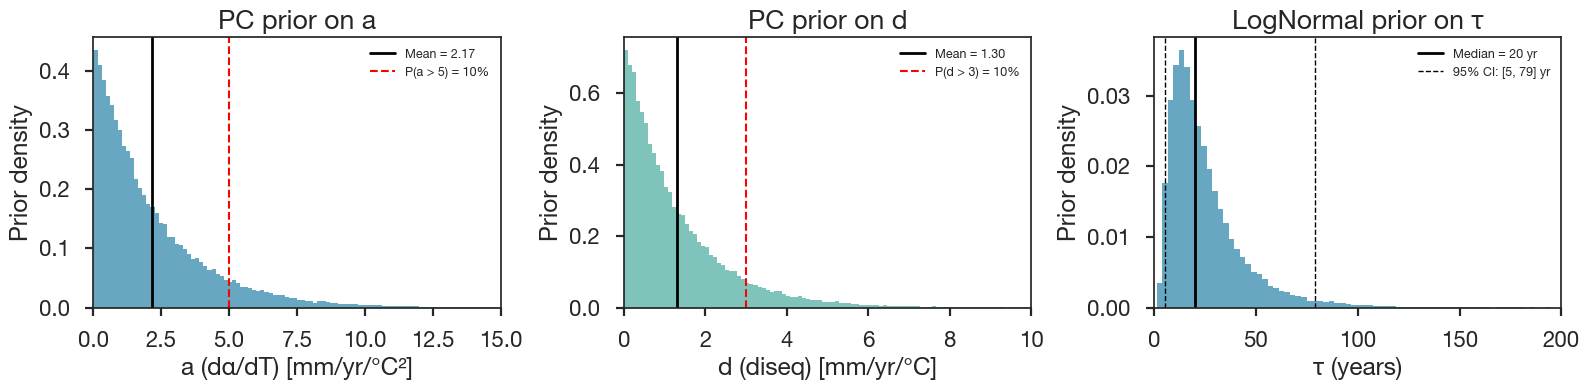

=== Full Prior Summary ===
  a (dα/dT): Exponential(mean = 2.17 mm/yr/°C²)
  b (α₀):    HalfNormal(σ = 10.0 mm/yr/°C)
  c (trend): Normal(2.0, 5.0 mm/yr)
  d (diseq): Exponential(mean = 1.30 mm/yr/°C)
  τ:         LogNormal(median=20 yr, 95% CI [5, 79] yr)
  σ_extra:   HalfCauchy(0, 5.0 mm)
  H₀:        Normal(H_obs[0], 50.0 mm)


In [5]:
# ============================================================
# Prior configuration (all in meters)
# ============================================================

# Quadratic coefficient a: Exponential (PC) prior
# Calibrated via tail probability: P(a > 5 mm/yr/°C²) = 10%
PRIOR_SCALE_A = calibrate_exponential_prior(
    prob_exceed=0.10,
    threshold=0.005,  # 5 mm/yr/°C² in m/yr/°C²
)

# Disequilibrium strength d: Exponential (PC) prior
# d=0 recovers the instantaneous model (no memory).
# Calibrated via P(d > 3 mm/yr/°C) = 10%
PRIOR_SCALE_D = calibrate_exponential_prior(
    prob_exceed=0.10,
    threshold=0.003,  # 3 mm/yr/°C in m/yr/°C
)

# Other priors unchanged
PRIOR_SCALE_B = 0.010           # HalfNormal sigma for b
PRIOR_C_MEAN = 0.002            # Normal mean for c
PRIOR_C_SIGMA = 0.005           # Normal sigma for c
PRIOR_LOG_TAU_MEAN = np.log(20) # LogNormal: median = 20 yr
PRIOR_LOG_TAU_SIGMA = 0.7       # LogNormal: log-space sigma
PRIOR_SIGMA_EXTRA_SCALE = 0.005 # HalfCauchy(5 mm)
PRIOR_H0_SIGMA = 0.050          # Normal sigma for H0

# --- Prior predictive check ---
pp_rates = prior_predictive_rate_check(
    PRIOR_SCALE_A, PRIOR_SCALE_B, PRIOR_C_MEAN, PRIOR_C_SIGMA,
    T_values=[0.5, 0.8, 1.0, 2.0, 4.0], seed=42,
)

print('=== Exponential (PC) Priors ===')
print(f'  a ~ Exponential(mean = {PRIOR_SCALE_A*M_TO_MM:.3f} mm/yr/°C²)')
print(f'    P(a > 5 mm/yr/°C²) = 0.10')
print(f'    P(a > 3 mm/yr/°C²) = {np.exp(-0.003/PRIOR_SCALE_A):.3f}')
print(f'    P(a > 1 mm/yr/°C²) = {np.exp(-0.001/PRIOR_SCALE_A):.3f}')
print(f'  d ~ Exponential(mean = {PRIOR_SCALE_D*M_TO_MM:.3f} mm/yr/°C)')
print(f'    P(d > 3 mm/yr/°C)  = 0.10')
print(f'    P(d > 1 mm/yr/°C)  = {np.exp(-0.001/PRIOR_SCALE_D):.3f}')
print()

print('=== Prior Predictive Rate Check (mm/yr, excl. d) ===')
print(f'  {"T (°C)":<8} {"Median":>8} {"5–95%":>18}')
print(f'  {"-"*36}')
for T, stats in pp_rates.items():
    print(f'  {T:<8.1f} {stats["median"]*M_TO_MM:8.1f} '
          f'[{stats["p5"]*M_TO_MM:7.1f}, {stats["p95"]*M_TO_MM:7.1f}]')
print()

# Visualise priors
tau_prior_samples = np.random.lognormal(PRIOR_LOG_TAU_MEAN,
                                         PRIOR_LOG_TAU_SIGMA, 50000)
tau_lo = np.exp(PRIOR_LOG_TAU_MEAN - 1.96 * PRIOR_LOG_TAU_SIGMA)
tau_hi = np.exp(PRIOR_LOG_TAU_MEAN + 1.96 * PRIOR_LOG_TAU_SIGMA)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: Exponential prior on a
ax = axes[0]
a_prior_samples = np.random.exponential(PRIOR_SCALE_A, 50000) * M_TO_MM
ax.hist(a_prior_samples[a_prior_samples < 15], bins=100, density=True,
        alpha=0.6, color='C0')
ax.axvline(PRIOR_SCALE_A * M_TO_MM, color='k', ls='-', lw=2,
           label=f'Mean = {PRIOR_SCALE_A*M_TO_MM:.2f}')
ax.axvline(5.0, color='red', ls='--', lw=1.5,
           label='P(a > 5) = 10%')
ax.set_xlabel('a (dα/dT) [mm/yr/°C²]')
ax.set_ylabel('Prior density')
ax.set_title('PC prior on a')
ax.legend(fontsize=9)
ax.set_xlim(0, 15)

# Middle: Exponential prior on d
ax = axes[1]
d_prior_samples = np.random.exponential(PRIOR_SCALE_D, 50000) * M_TO_MM
ax.hist(d_prior_samples[d_prior_samples < 10], bins=100, density=True,
        alpha=0.6, color='C2')
ax.axvline(PRIOR_SCALE_D * M_TO_MM, color='k', ls='-', lw=2,
           label=f'Mean = {PRIOR_SCALE_D*M_TO_MM:.2f}')
ax.axvline(3.0, color='red', ls='--', lw=1.5,
           label='P(d > 3) = 10%')
ax.set_xlabel('d (diseq) [mm/yr/°C]')
ax.set_ylabel('Prior density')
ax.set_title('PC prior on d')
ax.legend(fontsize=9)
ax.set_xlim(0, 10)

# Right: τ prior (unchanged)
ax = axes[2]
ax.hist(tau_prior_samples[tau_prior_samples < 300], bins=100,
        density=True, alpha=0.6, color='C0')
ax.axvline(20, color='k', ls='-', lw=2, label=f'Median = 20 yr')
ax.axvline(tau_lo, color='k', ls='--', lw=1,
           label=f'95% CI: [{tau_lo:.0f}, {tau_hi:.0f}] yr')
ax.axvline(tau_hi, color='k', ls='--', lw=1)
ax.set_xlabel('τ (years)')
ax.set_ylabel('Prior density')
ax.set_title('LogNormal prior on τ')
ax.legend(fontsize=9)
ax.set_xlim(0, 200)

plt.savefig(FIG_DIR / 'ratestate_priors.png',bbox_inches='tight')

plt.tight_layout()
plt.show()

print('=== Full Prior Summary ===')
print(f'  a (dα/dT): Exponential(mean = {PRIOR_SCALE_A*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b (α₀):    HalfNormal(σ = {PRIOR_SCALE_B*M_TO_MM:.1f} mm/yr/°C)')
print(f'  c (trend): Normal({PRIOR_C_MEAN*M_TO_MM:.1f}, {PRIOR_C_SIGMA*M_TO_MM:.1f} mm/yr)')
print(f'  d (diseq): Exponential(mean = {PRIOR_SCALE_D*M_TO_MM:.2f} mm/yr/°C)')
print(f'  τ:         LogNormal(median=20 yr, 95% CI [{tau_lo:.0f}, {tau_hi:.0f}] yr)')
print(f'  σ_extra:   HalfCauchy(0, {PRIOR_SIGMA_EXTRA_SCALE*M_TO_MM:.1f} mm)')
print(f'  H₀:        Normal(H_obs[0], {PRIOR_H0_SIGMA*M_TO_MM:.1f} mm)')

## §5 Satellite-Era Rate Prior

Quadratic fit to NASA satellite altimetry (1993–2023) with a rigorous
three-component error budget following Hamlington et al. (2024):

1. **Measurement errors** — Ablain et al. (2019) error covariance matrix
2. **Serial correlation** — Maul & Martin (1993) lag-1 inflation
3. **GIA uncertainty** — Caron et al. (2018), 0.15 mm/yr (1σ), rate only

This provides a bivariate Gaussian prior on (rate, accel) at the end of the
Frederikse record (~2018.5) that regularises the level-space models.

=== NASA Satellite Altimetry Quadratic Fit (1993–2023) ===
  method: full_error_budget
  n_obs: 1123 (~10-day cadence)
  R² = 0.9696
  Acceleration: 68.66 ± 59.24 μm/yr² (= 0.0687 ± 0.0592 mm/yr²)

  --- Midpoint comparison (2008.2) ---
                                     Ours (1σ)    Hamlington 90% CI
  ---------------------------------------------------------------
  Rate (mm/yr)                 3.235 ± 0.251     3.3 ± 0.3
  Accel (mm/yr²)              0.0687 ± 0.0395   0.08 ± 0.06

  --- Rate prior @ 2018.5 (σ inflated ×1.5) ---
  Rate:  3.941 ± 0.653 mm/yr (1σ)
  Accel: 68.66 ± 59.24 μm/yr² (1σ)
  Rate–accel correlation: 0.825

  Frederikse kinematics (20-yr) at 2018.5: 6.504 ± 0.824 mm/yr


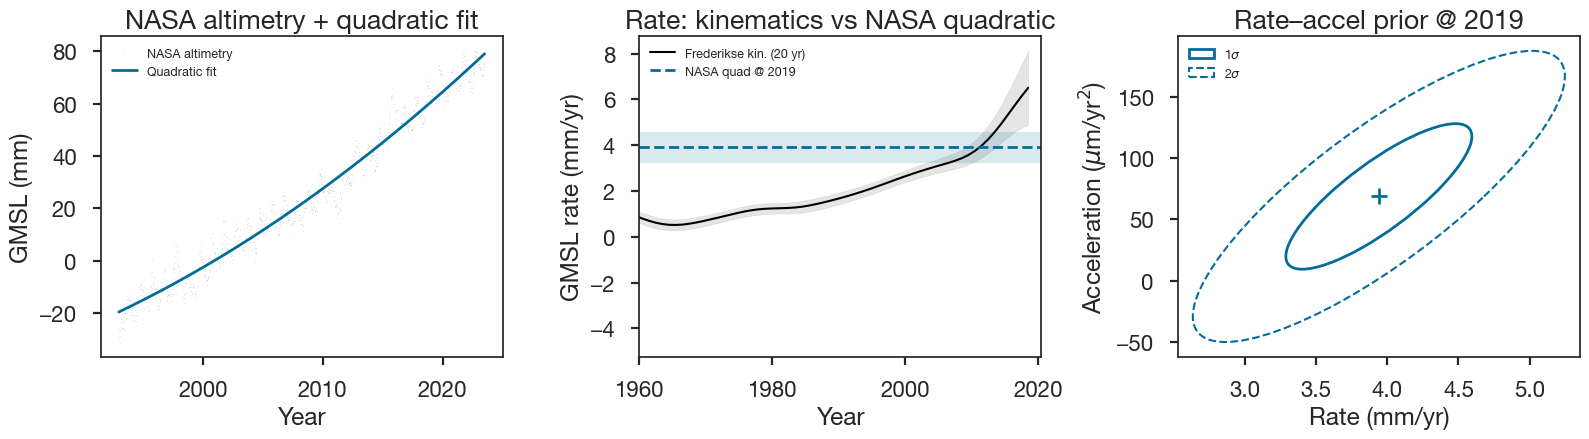

In [6]:
# ============================================================
# Satellite-era rate prior from NASA altimetry
# ============================================================
# Full error budget: measurement (Ablain 2019) + serial correlation
# (Maul & Martin 1993) + GIA (Caron 2018).
# Evaluated at 2018.5 (end of Frederikse record) with σ inflation
# of 1.5 to account for partial information overlap with the
# level-space likelihood.

sat_quad = fit_satellite_era_quadratic(
    time=nasa_time,
    gmsl=nasa_gmsl,
    sigma=None,                    # OLS — NASA σ is spatial variability
    t_start=1993.0,
    t_end=2023.5,                  # match Hamlington et al. (2024)
    eval_time=obs_years[-1],       # end of Frederikse record
    sigma_inflate=1.5,
    meas_cov_path=ABLAIN_COV_PATH,
    sigma_gia=0.15e-3,             # 0.15 mm/yr (1σ), Caron et al. 2018
)

# Also compute at midpoint for comparison with Hamlington
sat_quad_mid = fit_satellite_era_quadratic(
    time=nasa_time,
    gmsl=nasa_gmsl,
    sigma=None,
    t_start=1993.0,
    t_end=2023.5,
    eval_time=0.5 * (1993.0 + 2023.5),  # midpoint ~2008.3
    sigma_inflate=1.0,                    # no inflation for comparison
    meas_cov_path=ABLAIN_COV_PATH,
    sigma_gia=0.15e-3,
)

print('=== NASA Satellite Altimetry Quadratic Fit (1993–2023) ===')
print(f'  method: {sat_quad.fit_method}')
print(f'  n_obs: {sat_quad.n_obs} (~10-day cadence)')
print(f'  R² = {sat_quad.r2:.4f}')
print(f'  Acceleration: {sat_quad.accel*1e6:.2f} '
      f'± {sat_quad.accel_se*1e6:.2f} μm/yr² '
      f'(= {sat_quad.accel*M_TO_MM:.4f} '
      f'± {sat_quad.accel_se*M_TO_MM:.4f} mm/yr²)')
print()

# Midpoint comparison with Hamlington et al. (2024)
print(f'  --- Midpoint comparison ({sat_quad_mid.eval_time:.1f}) ---')
print(f'  {"":25} {"Ours (1σ)":>18} {"Hamlington 90% CI":>20}')
print(f'  {"-"*63}')
print(f'  {"Rate (mm/yr)":<25} '
      f'{sat_quad_mid.rate*M_TO_MM:8.3f} ± {sat_quad_mid.rate_se*M_TO_MM:.3f}'
      f'{"3.3 ± 0.3":>14}')
print(f'  {"Accel (mm/yr²)":<25} '
      f'{sat_quad_mid.accel*M_TO_MM:8.4f} ± {sat_quad_mid.accel_se*M_TO_MM:.4f}'
      f'{"0.08 ± 0.06":>14}')
print()

# Rate prior values (with σ inflation)
corr = (sat_quad.rate_accel_cov[0, 1]
        / np.sqrt(sat_quad.rate_accel_cov[0, 0]
                  * sat_quad.rate_accel_cov[1, 1]))
print(f'  --- Rate prior @ {sat_quad.eval_time:.1f} (σ inflated ×1.5) ---')
print(f'  Rate:  {sat_quad.rate*M_TO_MM:.3f} '
      f'± {sat_quad.rate_se*M_TO_MM:.3f} mm/yr (1σ)')
print(f'  Accel: {sat_quad.accel*1e6:.2f} '
      f'± {sat_quad.accel_se*1e6:.2f} μm/yr² (1σ)')
print(f'  Rate–accel correlation: {corr:.3f}')

# --- Diagnostic: compare with kinematics ---
kin = compute_kinematics(
    time=obs_years,
    value=H_obs_full,
    sigma=sigma_obs_fixed,
    span_years=20,
)
idx_end = np.argmin(np.abs(kin.time - sat_quad.eval_time))
print(f'\n  Frederikse kinematics (20-yr) at {kin.time[idx_end]:.1f}: '
      f'{kin.rate[idx_end]*M_TO_MM:.3f} '
      f'± {kin.rate_se[idx_end]*M_TO_MM:.3f} mm/yr')

# --- Figure: 3-panel diagnostic ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: NASA GMSL with quadratic fit overlay
ax = axes[0]
mask_plot = nasa_time <= 2023.5
ax.plot(nasa_time[mask_plot], nasa_gmsl[mask_plot] * M_TO_MM,
        '.', ms=1, alpha=0.3, color='grey', label='NASA altimetry')
dt_plot = np.linspace(0, 2023.5 - 1993.0, 300)
H_fit = (sat_quad.coefficients[0]
         + sat_quad.coefficients[1] * dt_plot
         + sat_quad.coefficients[2] * dt_plot**2) * M_TO_MM
ax.plot(dt_plot + 1993.0, H_fit, 'C0-', lw=2, label='Quadratic fit')
ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm)')
ax.set_title('NASA altimetry + quadratic fit')
ax.legend(fontsize=9)

# Middle: rate comparison
ax = axes[1]
ax.plot(kin.time, kin.rate * M_TO_MM, 'k-', lw=1.5,
        label='Frederikse kin. (20 yr)')
ax.fill_between(kin.time,
                (kin.rate - 1.96 * kin.rate_se) * M_TO_MM,
                (kin.rate + 1.96 * kin.rate_se) * M_TO_MM,
                alpha=0.2, color='grey')
ax.axhline(sat_quad.rate * M_TO_MM, color='C0', ls='--', lw=2,
           label=f'NASA quad @ {sat_quad.eval_time:.0f}')
ax.axhspan((sat_quad.rate - sat_quad.rate_se) * M_TO_MM,
           (sat_quad.rate + sat_quad.rate_se) * M_TO_MM,
           alpha=0.15, color='C0')
ax.set_xlabel('Year')
ax.set_ylabel('GMSL rate (mm/yr)')
ax.set_title('Rate: kinematics vs NASA quadratic')
ax.set_xlim(1960, sat_quad.eval_time + 2)
ax.legend(fontsize=9)

# Right: rate-accel joint prior ellipse (unfilled, distinct line styles)
ax = axes[2]
from matplotlib.patches import Ellipse
mean = np.array([sat_quad.rate * M_TO_MM, sat_quad.accel * 1e6])
cov_plot = np.array([
    [sat_quad.rate_accel_cov[0, 0] * M_TO_MM**2,
     sat_quad.rate_accel_cov[0, 1] * M_TO_MM * 1e6],
    [sat_quad.rate_accel_cov[1, 0] * M_TO_MM * 1e6,
     sat_quad.rate_accel_cov[1, 1] * 1e12],
])
eigvals, eigvecs = np.linalg.eigh(cov_plot)
angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
for nsig, ls, lw in [(1, '-', 2.0), (2, '--', 1.5)]:
    w = 2 * nsig * np.sqrt(eigvals[1])
    h = 2 * nsig * np.sqrt(eigvals[0])
    ell = Ellipse(mean, w, h, angle=angle, fill=False,
                  edgecolor='C0', lw=lw, ls=ls,
                  label=f'{nsig}$\\sigma$')
    ax.add_patch(ell)
ax.plot(*mean, 'C0+', ms=12, mew=2)
ax.set_xlabel('Rate (mm/yr)')
ax.set_ylabel('Acceleration ($\\mu$m/yr$^2$)')
ax.set_title(f'Rate\u2013accel prior @ {sat_quad.eval_time:.0f}')
ax.set_aspect('auto')
ax.autoscale()
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_satellite_era_prior.png',
            dpi=150, bbox_inches='tight')
plt.show()

## §6 MCMC Sampling

### Two-step initialisation strategy

The 5-regressor OLS problem ($I_2, I_1, I_0, I_S, \mathbf{1}$) is severely ill-conditioned because $I_S$ is strongly collinear with $I_1$ and $I_0$. OLS typically yields negative $d$ and $b$, violating the physical priors and placing walkers far from the posterior.

**Solution**: First fit the **instantaneous model** (the $\tau \to 0$ limit with $d=0$), which converges easily. Then initialise the rate-and-state sampler from its posterior: $(a, b, c)$ from the instantaneous fit, $d \approx 0$, and $\tau$ at the prior median. This gives walkers a feasible, high-probability starting point and lets the MCMC explore whether the data support $d > 0$ (and what $\tau$ is).

Settings: 64 walkers, 3000 burn-in, 5000 production steps. The nonlinearity from $\tau$ (ODE re-solved at each step) makes this ~3× more expensive per evaluation than the instantaneous model.

In [7]:
# ============================================================
# Step 1: Fit the INSTANTANEOUS model (τ→0 limit, d=0)
# ============================================================
print('='*70)
print('Step 1: Instantaneous model (τ→0 limit)')
print('='*70)
inst_result = fit_bayesian_level(
    H_obs=H_obs_full,
    sigma_obs=sigma_obs_fixed,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A,
    prior_scale_b=PRIOR_SCALE_B,
    prior_c_mean=PRIOR_C_MEAN,
    prior_c_sigma=PRIOR_C_SIGMA,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
    prior_H0_sigma=PRIOR_H0_SIGMA,
    n_samples=N_SAMPLES,
    n_walkers=N_WALKERS,
    n_burnin=1000,  # instantaneous model converges fast
    progress=True,
    seed=42,
    rate_prior=sat_quad,
    temperature_monthly=T_monthly_all,      # full record, not truncated
    time_monthly=time_monthly_all,          # avoids boundary effects on dT/dt
    obs_times=obs_years,
)

print(f'\nInstantaneous R² = {inst_result.r2:.4f}')
print(f'Coefficients (mm/yr): a={inst_result.physical_coefficients[0]*M_TO_MM:.3f}, '
      f'b={inst_result.physical_coefficients[1]*M_TO_MM:.3f}, '
      f'c={inst_result.physical_coefficients[2]*M_TO_MM:.3f}')

# ============================================================
# Step 2: Fit the RATE-AND-STATE model
# Initialise from order=1 (linear): a≈0, consistent with PC prior.
# Lets the MCMC decide whether a, d, or both explain nonlinearity.
# ============================================================
# Extend T_monthly_fit to ±5 yr beyond the Frederikse record so that
# the dT/dt estimate for the rate prior has a symmetric window.
# The ODE solve needs T(t) over the calibration period; extending
# a few years beyond is harmless (the ODE just runs a bit longer).
mask_berk_ext = ((time_monthly_all >= obs_years[0]) &
                 (time_monthly_all <= obs_years[-1] + 6.0))
T_monthly_ext = T_monthly_all[mask_berk_ext]
time_monthly_ext = time_monthly_all[mask_berk_ext]
# obs_idx must map into the extended grid
obs_idx_ext = np.array([
    np.argmin(np.abs(time_monthly_ext - yr)) for yr in obs_years
])

print('\n' + '='*70)
print('Step 2: Rate-and-state model (initialised from linear subspace)')
print('='*70)
state_result = fit_bayesian_state_level(
    H_obs=H_obs_full,
    sigma_obs=sigma_obs_fixed,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    T_monthly=T_monthly_ext,
    time_monthly=time_monthly_ext,
    obs_idx=obs_idx_ext,
    prior_scale_a=PRIOR_SCALE_A,
    prior_scale_b=PRIOR_SCALE_B,
    prior_c_mean=PRIOR_C_MEAN,
    prior_c_sigma=PRIOR_C_SIGMA,
    prior_scale_d=PRIOR_SCALE_D,
    prior_log_tau_mean=PRIOR_LOG_TAU_MEAN,
    prior_log_tau_sigma=PRIOR_LOG_TAU_SIGMA,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
    prior_H0_sigma=PRIOR_H0_SIGMA,
    n_samples=N_SAMPLES,
    n_walkers=N_WALKERS,
    n_burnin=N_BURNIN,
    progress=True,
    seed=42,
    init_from_level=inst_result,
    init_order=1,
    rate_prior=sat_quad,
)

# Summary table
print('\n' + '=' * 70)
print('Rate-and-State Posterior Summary (mm/yr)')
print('=' * 70)
names_phys = ['dα/dT', 'α₀', 'trend', 'd (diseq)']
print(f'{"Parameter":<14} {"Mean":>10} {"94% HDI":>24}')
print('-' * 50)
for k, name in enumerate(names_phys):
    v = state_result.physical_coefficients[k] * M_TO_MM
    hdi = state_result.physical_hdi_94[k] * M_TO_MM
    print(f'{name:<14} {v:10.3f}      [{hdi[0]:.3f}, {hdi[1]:.3f}]')

tau_post = state_result.tau_posterior
print(f'\nτ: median={np.median(tau_post):.1f} yr '
      f'[{np.percentile(tau_post, 3):.1f}, '
      f'{np.percentile(tau_post, 97):.1f}] (94% HDI)')
print(f'σ_extra: median={np.median(state_result.sigma_extra_posterior)*M_TO_MM:.2f} mm '
      f'[{np.percentile(state_result.sigma_extra_posterior, 3)*M_TO_MM:.2f}, '
      f'{np.percentile(state_result.sigma_extra_posterior, 97)*M_TO_MM:.2f}]')
print(f'R² = {state_result.r2:.4f}')

Step 1: Instantaneous model (τ→0 limit)
Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=2.17 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(2.0, 5.0 mm/yr), σ_extra~HC(5.0 mm)
  Rate prior: rate=3.94 ± 0.65 mm/yr, accel=68.66 ± 59.24 μm/yr², T_end=0.244 °C, dT/dt=17.18 m°C/yr
  OLS init: a=3.024, b=3.754, c=2.428 mm/yr, σ_extra=9.33 mm


  0%|          | 0/6000 [00:00<?, ?it/s]

  1%|          | 32/6000 [00:00<00:18, 315.97it/s]

  1%|          | 65/6000 [00:00<00:18, 323.51it/s]

  2%|▏         | 99/6000 [00:00<00:17, 329.44it/s]

...

100%|█████████▉| 7998/8000 [27:14<00:00,  5.04it/s]

100%|█████████▉| 7999/8000 [27:15<00:00,  5.04it/s]

100%|██████████| 8000/8000 [27:15<00:00,  5.08it/s]

100%|██████████| 8000/8000 [27:15<00:00,  4.89it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.031  ESS_bulk=197  ESS_tail=393
    alpha0: R-hat=1.042  ESS_bulk=171  ESS_tail=237
    trend: R-hat=1.035  ESS_bulk=155  ESS_tail=227
    d_diseq: R-hat=1.054  ESS_bulk=98  ESS_tail=89
    log_tau: R-hat=1.021  ESS_bulk=109  ESS_tail=379
    log_sigma_extra: R-hat=1.031  ESS_bulk=147  ESS_tail=296
    H0: R-hat=1.028  ESS_bulk=191  ESS_tail=809
  WARNINGS:
  d_diseq: R-hat = 1.054 > 1.05 — chains have NOT converged
  d_diseq: bulk ESS = 98 < 100 — increase samples or walkers
  d_diseq: tail ESS = 89 < 100 — tail estimates unreliable

  Posterior mean: a=4.601, b=5.214, c=2.670, d=0.654 mm/yr
  τ: median=16.7 yr [3.9, 80.3]
  σ_extra: median=1.27 mm [0.08, 3.56]
  R² = 0.9680,  acceptance = 0.40

Rate-and-State Posterior Summary (mm/yr)
Parameter            Mean                  94% HDI
--------------------------------------------------
dα/dT               4.601      [3.176, 6.110]
α₀                  5.214      [4.097, 6.358]
trend    

## §7 Convergence Diagnostics

Trace plots for all 7 parameters, with particular attention to $\log\tau$ mixing (the only nonlinear parameter).

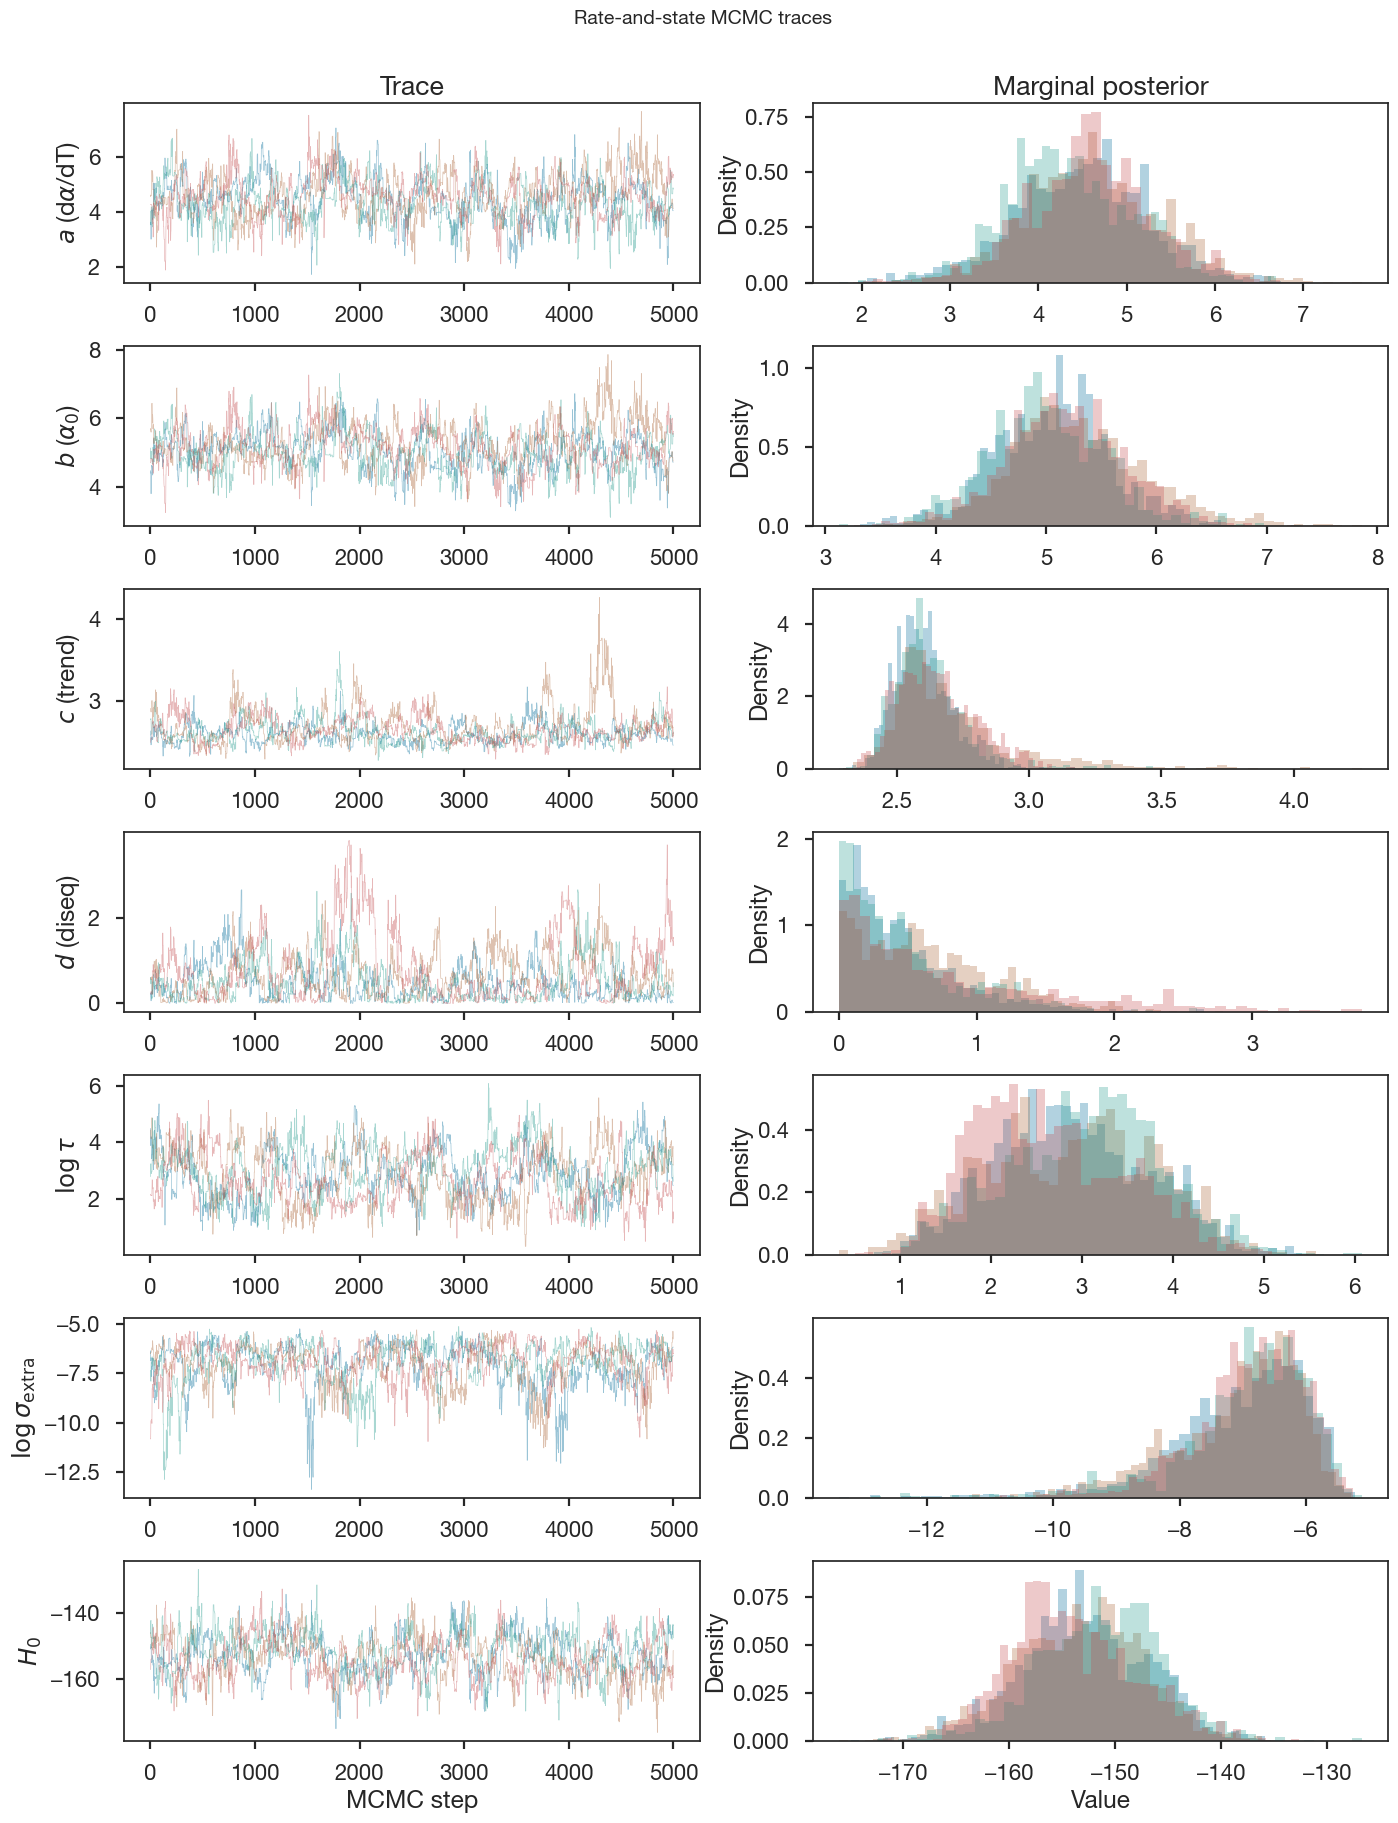

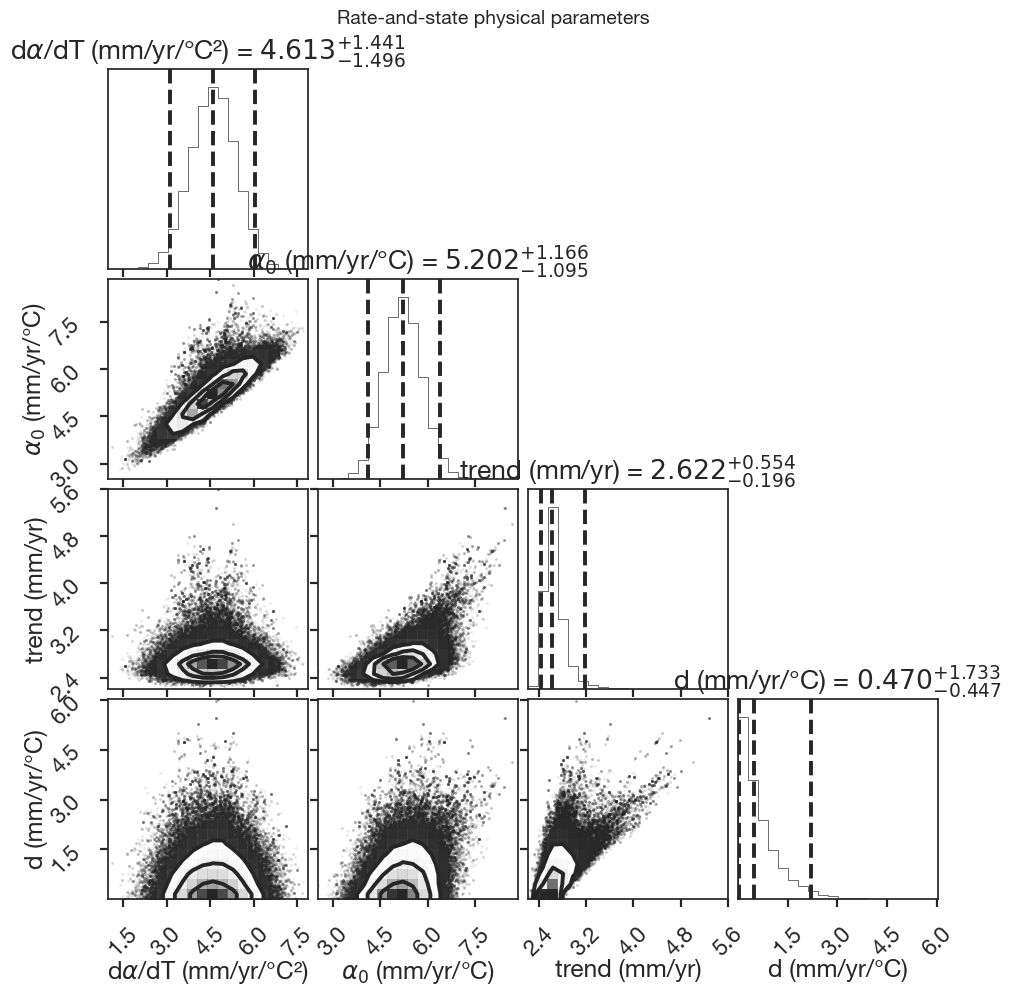

Acceptance fraction: 0.397
R-hat max: N/A
ESS min:   N/A
Converged: False


In [8]:
# ============================================================
# Trace plots (7 parameters)
# ============================================================
fig, axes = plt.subplots(7, 2, figsize=(14, 18))
param_labels = [
    r'$a$ (d$\alpha$/dT)', r'$b$ ($\alpha_0$)', r'$c$ (trend)',
    r'$d$ (diseq)', r'$\log\tau$', r'$\log\sigma_{\rm extra}$', r'$H_0$'
]
param_names_trace = [
    'dalpha_dT', 'alpha0', 'trend', 'd_diseq',
    'log_tau', 'log_sigma_extra', 'H0'
]
chain_full = state_result.trace.posterior

for i, (name, label) in enumerate(zip(param_names_trace, param_labels)):
    data = chain_full[name].values
    # Scale physical params to mm
    scale = M_TO_MM if i in [0, 1, 2, 3] else (M_TO_MM if i == 6 else 1.0)

    ax = axes[i, 0]
    for ch in range(data.shape[0]):
        ax.plot(data[ch] * scale, alpha=0.4, lw=0.5)
    ax.set_ylabel(label)
    if i == 0:
        ax.set_title('Trace')

    ax = axes[i, 1]
    for ch in range(data.shape[0]):
        ax.hist(data[ch].ravel() * scale, bins=50, alpha=0.3, density=True)
    ax.set_ylabel('Density')
    if i == 0:
        ax.set_title('Marginal posterior')

axes[-1, 0].set_xlabel('MCMC step')
axes[-1, 1].set_xlabel('Value')
plt.suptitle('Rate-and-state MCMC traces', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_traces.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Corner plot (a, b, c, d)
# ============================================================
try:
    import corner
    labels_corner = [
        r'd$\alpha$/dT (mm/yr/°C²)', r'$\alpha_0$ (mm/yr/°C)',
        r'trend (mm/yr)', r'd (mm/yr/°C)'
    ]
    fig_corner = corner.corner(
        state_result.posterior_samples * M_TO_MM,
        labels=labels_corner,
        quantiles=[0.03, 0.50, 0.97],
        show_titles=True,
        title_fmt='.3f',
    )
    fig_corner.suptitle('Rate-and-state physical parameters',
                        fontsize=14, y=1.02)
    plt.savefig(FIG_DIR / 'ratestate_corner.png', dpi=150,
                bbox_inches='tight')
    plt.show()
except ImportError:
    print('corner not installed \u2014 skipping')

# Convergence diagnostics
diag = state_result.sampler_diagnostics
print(f"Acceptance fraction: {diag['acceptance_fraction']:.3f}")
conv = diag.get('convergence', {})
if conv:
    print(f"R-hat max: {conv.get('rhat_max', 'N/A')}")
    print(f"ESS min:   {conv.get('ess_min', 'N/A')}")
    print(f"Converged: {conv.get('converged', 'N/A')}")

## §8 Projections

Project GMSL under SSP scenarios using the joint posterior samples of $(a, b, c, d, \tau)$. Historical temperature is prepended for ODE spin-up so the state variable has the correct initial condition at the start of each projection.

In [9]:
# ============================================================
# Rate-and-state projections
# ============================================================
mc_state = project_gmsl_state_ensemble(
    coefficients=state_result.physical_coefficients,
    coefficients_cov=state_result.physical_covariance,
    tau_samples=state_result.tau_posterior,
    temperature_projections=temp_projections,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=2000,
    posterior_samples=state_result.posterior_samples,
    seed=42,
)

# Instantaneous projections for comparison
mc_inst = project_gmsl_ensemble(
    coefficients=inst_result.physical_coefficients,
    coefficients_cov=inst_result.physical_covariance,
    temperature_projections=temp_projections,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=2000,
    posterior_samples=inst_result.posterior_samples,
    seed=42,
)

# Summary table
print('=' * 85)
print(f'Projection comparison at 2050, 2100 (mm rel. {BASELINE_YEAR:.0f})')
print('=' * 85)
for yr in [2050, 2100]:
    print(f'\n--- Year {yr} ---')
    print(f'{"SSP":<12} {"State med [5\u201395%]":>26} {"Instant. med [5\u201395%]":>26}')
    print('-' * 66)
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        # State model
        df_s = mc_state['scenarios'][ssp]
        idx_s = np.argmin(np.abs(df_s['decimal_year'].values - yr))
        g_s = df_s['gmsl'].iloc[idx_s] * M_TO_MM
        lo_s = df_s['gmsl_lower'].iloc[idx_s] * M_TO_MM
        hi_s = df_s['gmsl_upper'].iloc[idx_s] * M_TO_MM
        s_str = f'{g_s:6.0f}  [{lo_s:5.0f}, {hi_s:5.0f}]'

        # Instantaneous
        df_i = mc_inst['scenarios'][ssp]
        idx_i = np.argmin(np.abs(df_i['decimal_year'].values - yr))
        g_i = df_i['gmsl'].iloc[idx_i] * M_TO_MM
        lo_i = df_i['gmsl_lower'].iloc[idx_i] * M_TO_MM
        hi_i = df_i['gmsl_upper'].iloc[idx_i] * M_TO_MM
        i_str = f'{g_i:6.0f}  [{lo_i:5.0f}, {hi_i:5.0f}]'

        print(f'{ssp:<12} {s_str:>26} {i_str:>26}')

Projection comparison at 2050, 2100, 2150 (mm rel. 2005)

--- Year 2050 ---
SSP                   State med [5–95%]       Instant. med [5–95%]
------------------------------------------------------------------
SSP1-2.6            253  [  215,   289]        250  [  214,   287]
SSP2-4.5            277  [  234,   320]        275  [  233,   317]
SSP3-7.0            300  [  251,   348]        297  [  250,   345]
SSP5-8.5            345  [  285,   403]        343  [  284,   402]

--- Year 2100 ---
SSP                   State med [5–95%]       Instant. med [5–95%]
------------------------------------------------------------------
SSP1-2.6            780  [  650,   906]        764  [  639,   890]
SSP2-4.5           1304  [ 1044,  1557]       1287  [ 1032,  1546]
SSP3-7.0           1999  [ 1558,  2420]       1974  [ 1547,  2420]
SSP5-8.5           2772  [ 2129,  3388]       2742  [ 2117,  3397]

--- Year 2150 ---
SSP                   State med [5–95%]       Instant. med [5–95%]
---------------

## §9 Projection Comparison

Multi-panel comparison: rate-and-state vs instantaneous vs IPCC AR6.

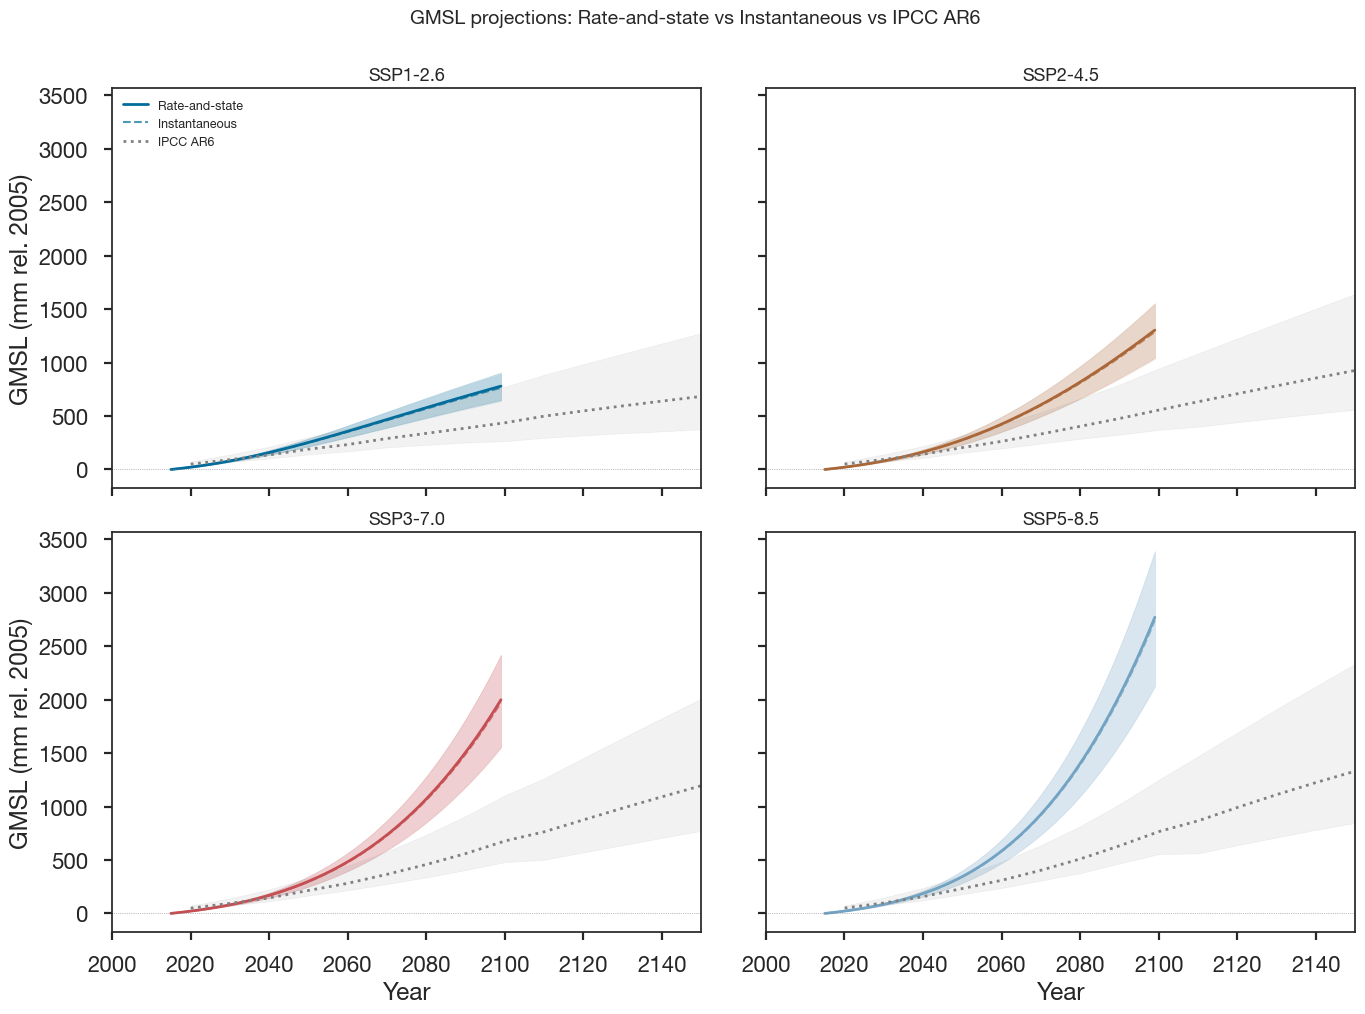

In [10]:
# ============================================================
# Multi-panel projection comparison
# ============================================================
ssp_colors = {
    'SSP1-2.6': 'C0', 'SSP2-4.5': 'C1',
    'SSP3-7.0': 'C3', 'SSP5-8.5': 'C4',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
for ax, ssp in zip(axes.flat,
                    ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']):
    color = ssp_colors[ssp]

    # State model
    df_s = mc_state['scenarios'][ssp]
    t_s = df_s['decimal_year'].values
    ax.fill_between(t_s, df_s['gmsl_lower']*M_TO_MM,
                    df_s['gmsl_upper']*M_TO_MM,
                    alpha=0.2, color=color)
    ax.plot(t_s, df_s['gmsl']*M_TO_MM, '-', color=color, lw=2,
            label=f'Rate-and-state')

    # Instantaneous
    df_i = mc_inst['scenarios'][ssp]
    t_i = df_i['decimal_year'].values
    ax.plot(t_i, df_i['gmsl']*M_TO_MM, '--', color=color, lw=1.5,
            alpha=0.7, label=f'Instantaneous')
    ax.fill_between(t_i, df_i['gmsl_lower']*M_TO_MM,
                    df_i['gmsl_upper']*M_TO_MM,
                    alpha=0.08, color=color)

    # IPCC
    if ssp in ipcc_gmsl:
        ipcc = ipcc_gmsl[ssp]
        ipcc_t = np.array([
            t.year + (t.month - 0.5) / 12 for t in ipcc.index
        ])
        if 'gmsl' in ipcc.columns:
            ax.plot(ipcc_t, ipcc['gmsl'].values*M_TO_MM, ':',
                    color=f'gray', lw=2, label='IPCC AR6')
            if 'gmsl_lower' in ipcc.columns:
                ax.fill_between(ipcc_t,
                                ipcc['gmsl_lower'].values*M_TO_MM,
                                ipcc['gmsl_upper'].values*M_TO_MM,
                                alpha=0.1, color='gray')

    ax.set_title(ssp, fontsize=13)
    ax.axhline(0, color='gray', ls=':', lw=0.5)
    if ax in axes[1]:
        ax.set_xlabel(f'Year')
    if ax in axes[:, 0]:
        ax.set_ylabel(f'GMSL (mm rel. {BASELINE_YEAR:.0f})')

axes[0, 0].legend(fontsize=9, loc='upper left')
axes[0, 0].set_xlim(2000, 2150)
plt.suptitle('GMSL projections: Rate-and-state vs Instantaneous vs IPCC AR6',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_projections.png', dpi=150,
            bbox_inches='tight')
plt.show()

## §10 Variance Decomposition

Variance Decomposition (mm)
  Year   σ_constr   σ_scenario    σ_ice    σ_total
--------------------------------------------------
  2050       28.4         33.9     75.0       87.1
  2075       94.9        230.6    223.7      335.0
  2100      219.7        748.5    543.7      950.9
  2125      219.7        748.5   1274.5     1494.3
  2150      219.7        748.5   2941.6     3043.2


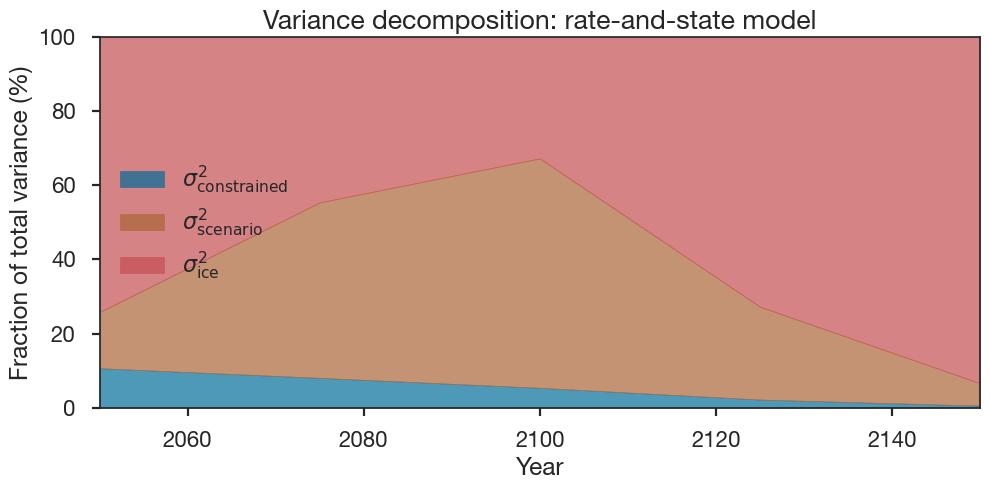

In [11]:
# ============================================================
# Variance decomposition
# ============================================================
target_years = [2050, 2075, 2100, 2125, 2150]

# σ_constrained: average within-scenario 5–95% range / (2 * Z_90)
# (for Gaussian, 90% range ≈ 3.29σ)
sigma_constrained = {}
for yr in target_years:
    spreads = []
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        df_s = mc_state['scenarios'][ssp]
        idx = np.argmin(np.abs(df_s['decimal_year'].values - yr))
        spread = (df_s['gmsl_upper'].iloc[idx] -
                  df_s['gmsl_lower'].iloc[idx]) * M_TO_MM
        spreads.append(spread)
    sigma_constrained[yr] = np.mean(spreads) / (2 * Z_90)

# σ_scenario: std of medians across SSPs
sigma_scenario = {}
for yr in target_years:
    medians = []
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        df_s = mc_state['scenarios'][ssp]
        idx = np.argmin(np.abs(df_s['decimal_year'].values - yr))
        medians.append(df_s['gmsl'].iloc[idx] * M_TO_MM)
    sigma_scenario[yr] = np.std(medians)

# σ_ice: computed from WAIS projection samples (meters -> mm)
from component_io import load_component
wais_data = load_component('wais')
wais_proj_years = wais_data['proj_years']
sigma_ice_approx = {}
for yr in target_years:
    idx_yr = np.argmin(np.abs(wais_proj_years - yr))
    # Average sigma across SSPs for a scenario-independent ice uncertainty
    ssp_sigmas = []
    for ssp in wais_data['projections']:
        samples = wais_data['projections'][ssp]['samples']
        ssp_sigmas.append(np.std(samples[:, idx_yr]) * M_TO_MM)
    sigma_ice_approx[yr] = np.mean(ssp_sigmas)

print('=' * 70)
print('Variance Decomposition (mm)')
print('=' * 70)
print(f'{"Year":>6} {"σ_constr":>10} {"σ_scenario":>12} '
      f'{"σ_ice":>8} {"σ_total":>10}')
print('-' * 50)
for yr in target_years:
    sc = sigma_constrained[yr]
    ss = sigma_scenario[yr]
    si = sigma_ice_approx.get(yr, 0)
    st = np.sqrt(sc**2 + ss**2 + si**2)
    print(f'{yr:>6} {sc:10.1f} {ss:12.1f} {si:8.1f} {st:10.1f}')

# ---- Stacked area chart ----
fig, ax = plt.subplots(figsize=(10, 5))
yrs = np.array(target_years)
v_c = np.array([sigma_constrained[y]**2 for y in yrs])
v_s = np.array([sigma_scenario[y]**2 for y in yrs])
v_i = np.array([sigma_ice_approx.get(y, 0)**2 for y in yrs])
v_total = v_c + v_s + v_i

ax.fill_between(yrs, 0, v_c/v_total*100, alpha=0.7, color='C0',
                label=r'$\sigma^2_{\rm constrained}$')
ax.fill_between(yrs, v_c/v_total*100, (v_c+v_s)/v_total*100,
                alpha=0.7, color='C1',
                label=r'$\sigma^2_{\rm scenario}$')
ax.fill_between(yrs, (v_c+v_s)/v_total*100, 100,
                alpha=0.7, color='C3',
                label=r'$\sigma^2_{\rm ice}$')
ax.set_xlabel('Year')
ax.set_ylabel('Fraction of total variance (%)')
ax.set_title('Variance decomposition: rate-and-state model')
ax.legend(loc='center left')
ax.set_ylim(0, 100)
ax.set_xlim(yrs[0], yrs[-1])
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_variance_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()

## §11 Export

In [12]:
# ============================================================
# Export all results to a single HDF5 file
# ============================================================
import h5py

H5_OUT = DATA_DIR / 'processed' / 'bayesian_ratestate_posterior.h5'

# Write to temp file, then replace (avoids Dropbox lock conflicts)
import tempfile, shutil
_tmp_fd, _tmp_path = tempfile.mkstemp(suffix='.h5', dir=str(DATA_DIR / 'processed'))
os.close(_tmp_fd)

with h5py.File(_tmp_path, 'w') as hf:
    hf.attrs['model'] = 'bayesian_rate_and_state'
    hf.attrs['description'] = (
        'Rate-and-state Bayesian level-space calibration with relaxation time tau. '
        'All sea-level values in meters, temperature in deg C, time in years.'
    )
    hf.attrs['baseline_year'] = BASELINE_YEAR
    hf.attrs['saved_at'] = str(pd.Timestamp.now(tz='UTC'))

    # --- Calibration metadata ---
    cal = hf.create_group('calibration')
    cal.attrs['n_obs'] = len(H_obs_full)
    cal.attrs['obs_range'] = [float(obs_years[0]), float(obs_years[-1])]
    cal.attrs['r_squared'] = float(state_result.r2)
    # Coefficients in internal units (meters)
    cal.create_dataset('coefficients', data=state_result.physical_coefficients)
    cal.attrs['param_names'] = ['dalpha_dT', 'alpha0', 'trend', 'd_diseq']
    cal.attrs['param_units'] = ['m/yr/C^2', 'm/yr/C', 'm/yr', 'm/yr/C']
    cal.create_dataset('covariance', data=state_result.physical_covariance)

    # --- Priors ---
    priors = hf.create_group('priors')
    priors.attrs['a'] = f'Exponential(mean={PRIOR_SCALE_A*M_TO_MM:.2f} mm/yr/C^2)'
    priors.attrs['b'] = f'HalfNormal(sigma={PRIOR_SCALE_B*M_TO_MM:.1f} mm/yr/C)'
    priors.attrs['c'] = f'Normal({PRIOR_C_MEAN*M_TO_MM:.1f}, {PRIOR_C_SIGMA*M_TO_MM:.1f} mm/yr)'
    priors.attrs['d'] = f'Exponential(mean={PRIOR_SCALE_D*M_TO_MM:.2f} mm/yr/C)'
    priors.attrs['tau'] = f'LogNormal(log({np.exp(PRIOR_LOG_TAU_MEAN):.0f}), {PRIOR_LOG_TAU_SIGMA})'
    priors.attrs['sigma_extra'] = f'HalfCauchy(0, {PRIOR_SIGMA_EXTRA_SCALE*M_TO_MM:.1f} mm)'
    priors.attrs['H0'] = f'Normal(H_obs[0], {PRIOR_H0_SIGMA*M_TO_MM:.1f} mm)'

    # --- Posterior samples ---
    post = hf.create_group('posterior')
    post.attrs['param_names'] = ['dalpha_dT', 'alpha0', 'trend', 'd_diseq']
    post.attrs['param_units'] = ['m/yr/C^2', 'm/yr/C', 'm/yr', 'm/yr/C']
    # Subsample posterior to N_EXPORT draws (full chain is 320k, wasteful)
    N_EXPORT = 2000
    _rng_sub = np.random.default_rng(42)
    _idx_sub = _rng_sub.choice(len(state_result.tau_posterior), size=N_EXPORT, replace=False)
    post.create_dataset('coefficients', data=state_result.posterior_samples[_idx_sub])
    post.create_dataset('tau', data=state_result.tau_posterior[_idx_sub])
    post.create_dataset('H0', data=state_result.H0_posterior[_idx_sub])
    post.create_dataset('sigma_extra', data=state_result.sigma_extra_posterior[_idx_sub])

    # --- Projections (full time series per SSP) ---
    proj_grp = hf.create_group('projections')
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        df_s = mc_state['scenarios'][ssp]
        sg = proj_grp.create_group(ssp)
        sg.create_dataset('time', data=df_s['decimal_year'].values)
        sg.create_dataset('gmsl_median', data=df_s['gmsl'].values)
        sg.create_dataset('gmsl_lower', data=df_s['gmsl_lower'].values)
        sg.create_dataset('gmsl_upper', data=df_s['gmsl_upper'].values)
        sg.attrs['units'] = 'meters'
        # Summary at 2100
        idx_2100 = np.argmin(np.abs(df_s['decimal_year'].values - 2100))
        sg.attrs['median_at_2100_m'] = float(df_s['gmsl'].iloc[idx_2100])
        sg.attrs['p5_at_2100_m'] = float(df_s['gmsl_lower'].iloc[idx_2100])
        sg.attrs['p95_at_2100_m'] = float(df_s['gmsl_upper'].iloc[idx_2100])

    # --- Rate-vs-temperature curve ---
    T_grid = np.linspace(-0.7, 0.5, 200)
    n_post = N_EXPORT
    _post_sub = state_result.posterior_samples[_idx_sub]

    rate_eq_samples = np.zeros((n_post, len(T_grid)))
    for k in range(n_post):
        a_k, b_k, c_k, d_k = _post_sub[k]
        rate_eq_samples[k] = (a_k * T_grid**2 + b_k * T_grid + c_k) * M_TO_MM

    rate_grp = hf.create_group('rate_vs_T')
    rate_grp.attrs['description'] = (
        'Equilibrium rate (d*(S-T)=0) as a function of temperature. '
        'For transient rates at specific epochs, use the projection data.'
    )
    rate_grp.create_dataset('T_grid_C', data=T_grid)
    rate_grp.create_dataset('rate_median_mm_yr', data=np.median(rate_eq_samples, axis=0))
    rate_grp.create_dataset('rate_p5_mm_yr', data=np.percentile(rate_eq_samples, 5, axis=0))
    rate_grp.create_dataset('rate_p95_mm_yr', data=np.percentile(rate_eq_samples, 95, axis=0))

    # --- Sensitivity curve: dRate/dT = 2*a*T + b (equilibrium) ---
    sens_eq_samples = np.zeros((n_post, len(T_grid)))
    for k in range(n_post):
        a_k, b_k, c_k, d_k = _post_sub[k]
        sens_eq_samples[k] = (2 * a_k * T_grid + b_k) * M_TO_MM

    sens_grp = hf.create_group('sensitivity_vs_T')
    sens_grp.attrs['description'] = (
        'Equilibrium sensitivity dRate/dT = 2*a*T + b (mm/yr per deg C) '
        'as a function of temperature.'
    )
    sens_grp.create_dataset('T_grid_C', data=T_grid)
    sens_grp.create_dataset('sensitivity_median_mm_yr_C', data=np.median(sens_eq_samples, axis=0))
    sens_grp.create_dataset('sensitivity_p5_mm_yr_C', data=np.percentile(sens_eq_samples, 5, axis=0))
    sens_grp.create_dataset('sensitivity_p95_mm_yr_C', data=np.percentile(sens_eq_samples, 95, axis=0))

    # --- Record-averaged sensitivity ---
    T_fred_start, T_fred_end = -0.6, 0.244
    avg_sens_samples = (
        _post_sub[:, 0] * (T_fred_start + T_fred_end)
        + _post_sub[:, 1]
    ) * M_TO_MM

    avg_grp = hf.create_group('record_averaged_sensitivity')
    avg_grp.attrs['T_start_C'] = T_fred_start
    avg_grp.attrs['T_end_C'] = T_fred_end
    avg_grp.attrs['description'] = (
        'Average sensitivity over the Frederikse record temperature range. '
        'Compare with Rahmstorf (2007) value of 3.4 mm/yr/deg C.'
    )
    avg_grp.create_dataset('median_mm_yr_C', data=float(np.median(avg_sens_samples)))
    avg_grp.create_dataset('p5_mm_yr_C', data=float(np.percentile(avg_sens_samples, 5)))
    avg_grp.create_dataset('p95_mm_yr_C', data=float(np.percentile(avg_sens_samples, 95)))

shutil.move(_tmp_path, str(H5_OUT))

print(f'All results saved to {H5_OUT}')
print(f'  Posterior shape: {state_result.posterior_samples.shape}')
print(f'  Projections: {", ".join(mc_state["scenarios"].keys())}')
print(f'  Rate curve T range: [{T_grid[0]:.1f}, {T_grid[-1]:.1f}] deg C')
print(f'  Record-averaged sensitivity: '
      f'{np.median(avg_sens_samples):.1f} '
      f'[{np.percentile(avg_sens_samples, 5):.1f}, '
      f'{np.percentile(avg_sens_samples, 95):.1f}] mm/yr/deg C')

# ---- Print summary ----
print('\n' + '=' * 70)
print('RATE-AND-STATE MODEL \u2014 SUMMARY')
print('=' * 70)
print(f"\nCalibration ({obs_years[0]:.0f}\u2013{obs_years[-1]:.0f}, n={len(H_obs_full)}):")
print(f"  R\u00b2 = {state_result.r2:.4f}")
for i, name in enumerate(['dalpha_dT', 'alpha0', 'trend', 'd_diseq']):
    v = state_result.physical_coefficients[i] * M_TO_MM
    hdi = state_result.physical_hdi_94[i] * M_TO_MM
    print(f'  {name}: {v:.3f} [{hdi[0]:.3f}, {hdi[1]:.3f}] mm/yr')
print(f"  \u03c4: {np.median(state_result.tau_posterior):.1f} "
      f"[{np.percentile(state_result.tau_posterior, 3):.1f}, "
      f"{np.percentile(state_result.tau_posterior, 97):.1f}] yr")
print(f"  \u03c3_extra: {np.median(state_result.sigma_extra_posterior)*M_TO_MM:.2f} "
      f"[{np.percentile(state_result.sigma_extra_posterior, 3)*M_TO_MM:.2f}, "
      f"{np.percentile(state_result.sigma_extra_posterior, 97)*M_TO_MM:.2f}] mm")

print(f'\nProjections at 2100 (mm, relative to {BASELINE_YEAR:.0f}):')
for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    df_s = mc_state['scenarios'][ssp]
    idx = np.argmin(np.abs(df_s['decimal_year'].values - 2100))
    med = df_s['gmsl'].iloc[idx] * M_TO_MM
    lo = df_s['gmsl_lower'].iloc[idx] * M_TO_MM
    hi = df_s['gmsl_upper'].iloc[idx] * M_TO_MM
    print(f"  {ssp}: {med:.0f} [{lo:.0f}, {hi:.0f}]")

All results saved to ../data/processed/bayesian_ratestate_posterior.h5
  Posterior shape: (320000, 4)
  Projections: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
  Rate curve T range: [-0.7, 0.5] deg C
  Record-averaged sensitivity: 3.5 [3.0, 4.2] mm/yr/deg C

RATE-AND-STATE MODEL — SUMMARY

Calibration (1901–2019, n=119):
  R² = 0.9680
  dalpha_dT: 4.601 [3.176, 6.110] mm/yr
  alpha0: 5.214 [4.097, 6.358] mm/yr
  trend: 2.670 [2.373, 3.024] mm/yr
  d_diseq: 0.654 [0.000, 1.812] mm/yr
  τ: 16.7 [3.9, 80.3] yr
  σ_extra: 1.27 [0.08, 3.56] mm

Projections at 2100 (mm, relative to 2000):
  SSP1-2.6: 780 [650, 906]
  SSP2-4.5: 1304 [1044, 1557]
  SSP3-7.0: 1999 [1558, 2420]
  SSP5-8.5: 2772 [2129, 3388]
